# FraudGuard: Hybrid Machine Learning Approach for Transaction Security
**Nama:** Arif Purnomo Aji
**| Tujuan:** Menggunakan Clustering untuk pelabelan data transaksi dan Klasifikasi untuk mendeteksi potensi fraud.
**| Submission:** Membangun Proyek Machine Learning (DICODING)

Import Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# Set style
sns.set(style="whitegrid")

Memuat Data & Inspeksi Awal

In [3]:
# Load dataset
df = pd.read_csv('dataset_clustering_project.csv')

# Menampilkan 5 data teratas
print("Tampilan 5 Data Teratas:")
display(df.head())

# Menampilkan informasi struktur data
print("\nInformasi Dataset:")
df.info()

# Statistik Deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

Tampilan 5 Data Teratas:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39



Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance 

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


Visualisasi EDA

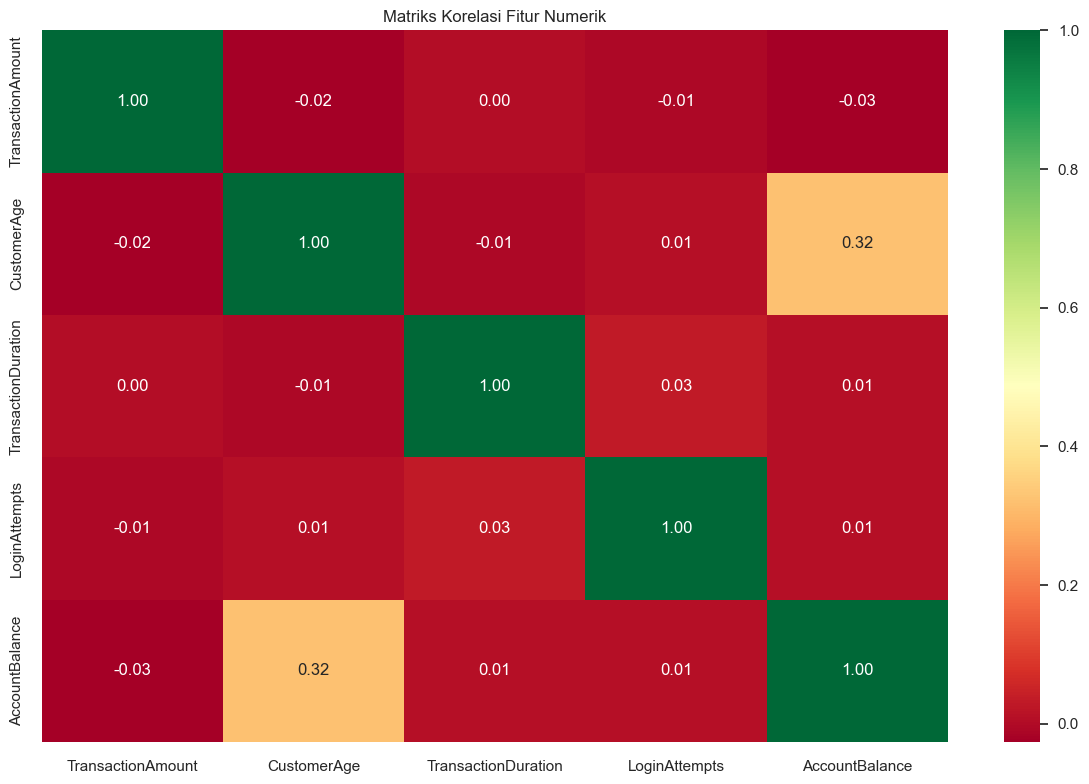

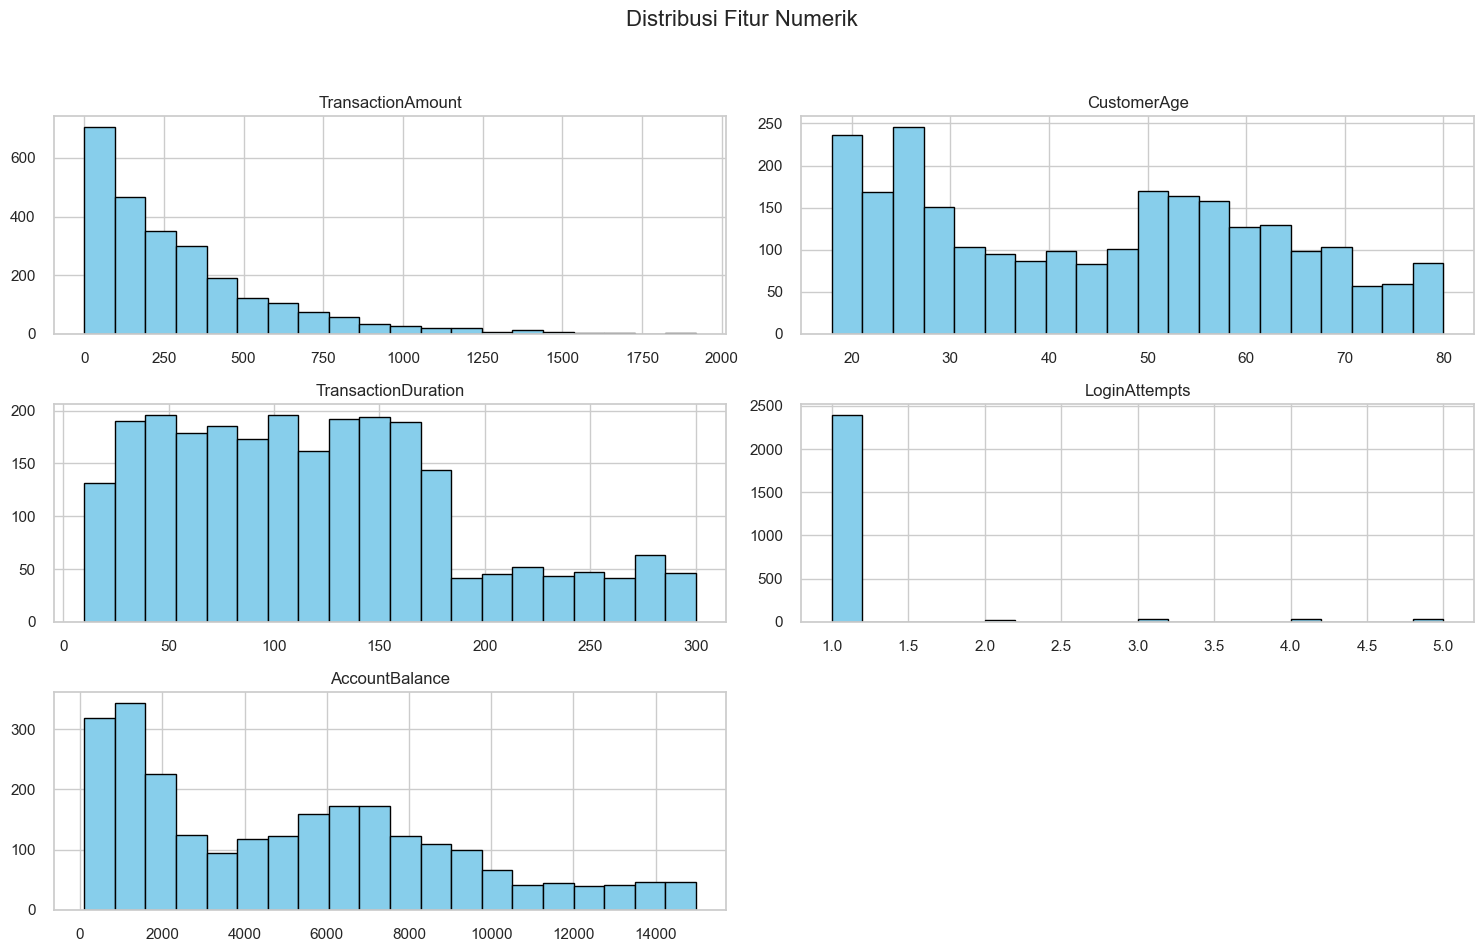

In [4]:
# 1. Matriks Korelasi
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout() # Mencegah label terpotong
plt.show()

# 2. Histogram untuk melihat distribusi
df.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Pembersihan & Drop Kolom

In [5]:
# 1. Mengecek missing values dan duplikat
print(f"Jumlah Missing Values:\n{df.isnull().sum()}")
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

# 2. Menangani missing values dan duplikat
df_clean = df.dropna().drop_duplicates()

# 3. Menghapus kolom ID, Address, dan Date sesuai kriteria
# Kolom-kolom ini tidak memberikan nilai pada pola clustering
cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID', 'TransactionDate']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

print(f"\nUkuran dataset setelah pembersihan: {df_clean.shape}")

Jumlah Missing Values:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

Jumlah Data Duplikat: 21

Ukuran dataset setelah pembersihan: (2135, 11)


Outlier Handling & Binning

In [6]:
# 4. Handling Outlier - Menggunakan metode sederhana (drop)
# TransactionAmount
Q1 = df_clean['TransactionAmount'].quantile(0.25)
Q3 = df_clean['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['TransactionAmount'] >= lower_bound) & (df_clean['TransactionAmount'] <= upper_bound)]

# 5. Binning Data
# Bagi TransactionAmount menjadi 3 kategori: Low, Medium, High
df_clean['Amount_Bin'] = pd.cut(df_clean['TransactionAmount'], bins=3, labels=['Low', 'Medium', 'High'])

# Encode hasil binning menggunakan LabelEncoder
le_bin = LabelEncoder()
df_clean['Amount_Bin'] = le_bin.fit_transform(df_clean['Amount_Bin'])

print("Binning berhasil dilakukan pada kolom TransactionAmount.")

Binning berhasil dilakukan pada kolom TransactionAmount.


Encoding & Scaling

In [7]:
# 6. Feature Encoding untuk fitur kategorikal lainnya
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# 7. Feature Scaling (Skilled)
scaler = StandardScaler()
# Skalakan fitur numerik untuk proses clustering
numeric_cols = df_clean.columns # Mengambil semua kolom yang sudah jadi angka
df_scaled = scaler.fit_transform(df_clean)

print("Semua fitur telah di-encode dan di-scale.")

Semua fitur telah di-encode dan di-scale.


PCA & Visualisasi Elbow Method

Menentukan jumlah cluster optimal...


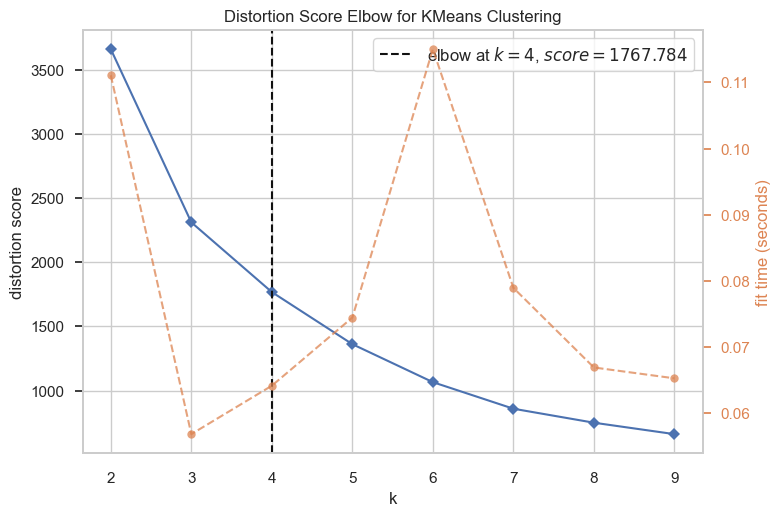

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
# 1. Membangun model PCA untuk reduksi dimensi
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Simpan model PCA sesuai instruksi
joblib.dump(pca, "PCA_model_clustering.h5")

# 2. Visualisasi Elbow Method untuk menentukan K terbaik
print("Menentukan jumlah cluster optimal...")
model_kmeans = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model_kmeans, k=(2,10))
visualizer.fit(df_pca)
visualizer.show()

Menjalankan K-Means & Evaluasi

In [9]:
# 3. Mengambil nilai K optimal dari visualizer
k_best = visualizer.elbow_value_
print(f"Jumlah cluster optimal yang dipilih: {k_best}")

# 4. Membangun model K-Means
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_pca)

# 5. Menghitung Silhouette Score
score = silhouette_score(df_pca, clusters)
print(f"Silhouette Score untuk {k_best} cluster: {score:.4f}")

# 6. Simpan model clustering utama
joblib.dump(kmeans, "model_clustering.h5")

Jumlah cluster optimal yang dipilih: 4
Silhouette Score untuk 4 cluster: 0.4200


['model_clustering.h5']

Visualisasi Hasil Clustering

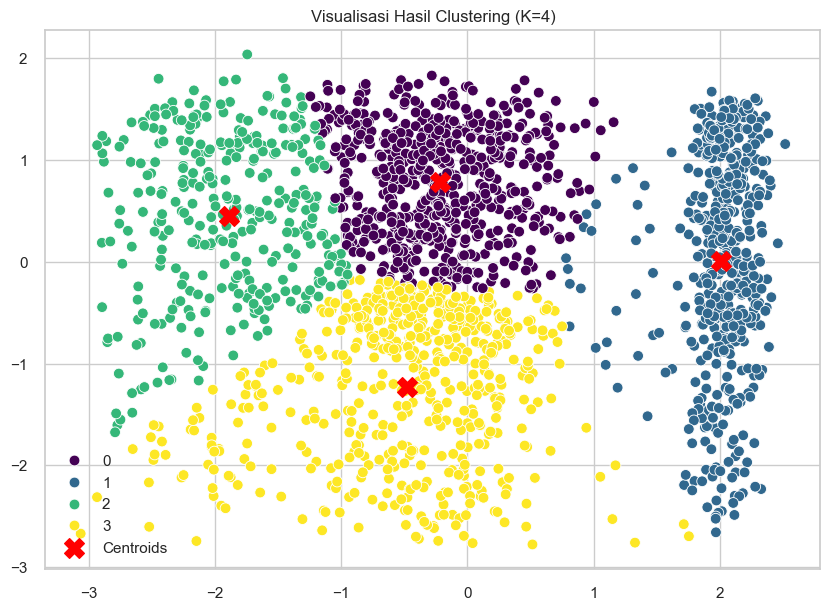

In [10]:
# Membuat visualisasi sebaran cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=clusters, palette='viridis', s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Centroids')
plt.title(f"Visualisasi Hasil Clustering (K={k_best})")
plt.legend()
plt.show()

Analisis Karakteristik & Ekspor Data

In [11]:
# 1. Menggabungkan hasil cluster ke dataframe asli
df_clean['Target'] = clusters

# 2. Analisis Deskriptif Fitur Numerik
# Rata-rata (mean), minimal, dan maksimal tiap cluster
cluster_analysis = df_clean.groupby('Target').agg({
    'TransactionAmount': ['mean', 'min', 'max', 'count'],
    'Amount_Bin': ['mean'] # Hasil binning yang kita buat tadi
})
print("Analisis Statistik per Cluster:")
display(cluster_analysis)

# 3. Menyimpan data hasil clustering ke CSV
# Data akan memiliki kolom 'Target' yang berfungsi sebagai label
df_clean.to_csv('data_clustering_inverse.csv', index=False)
print("\nFile 'data_clustering_inverse.csv' berhasil disimpan!")

Analisis Statistik per Cluster:


TransactionAmount                     Amount_Bin
                    mean   min     max count       mean
Target                                                 
0             232.112105  0.32  886.19   646   1.140867
1             267.739070  0.26  903.19   516   1.114341
2             245.326932  1.93  870.43   339   1.147493
3             283.382107  1.82  896.79   541   1.203327


File 'data_clustering_inverse.csv' berhasil disimpan!


Klasifikasi & Hyperparameter Tuning

In [12]:
# 1. Memisahkan Fitur dan Target
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

# 2. Pembagian Dataset (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Decision Tree dengan Hyperparameter Tuning
print("Memulai proses Hyperparameter Tuning...")
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

dt_model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. Simpan Model Sesuai Instruksi
joblib.dump(grid_search.best_estimator_, "decision_tree_model.h5")
joblib.dump(grid_search.best_estimator_, "tuning_classification.h5")

# 5. Evaluasi Model Lengkap
y_pred = grid_search.predict(X_test)
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

print(f"Parameter Terbaik: {grid_search.best_params_}")

Memulai proses Hyperparameter Tuning...

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       132
           1       1.00      0.97      0.98        96
           2       0.93      0.91      0.92        70
           3       0.89      0.92      0.91       111

    accuracy                           0.94       409
   macro avg       0.94      0.94      0.94       409
weighted avg       0.94      0.94      0.94       409

Parameter Terbaik: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}


Tahap Akhir: Finalisasi Data & Model

In [14]:
# Verifikasi file output penting
import os

files_to_check = [
    'PCA_model_clustering.h5', 
    'model_clustering.h5', 
    'data_clustering_inverse.csv', 
    'decision_tree_model.h5', 
    'tuning_classification.h5'
]

print("--- Status File Output ---")
for file in files_to_check:
    if os.path.exists(file):
        print(f"✅ {file} : Tersedia")
    else:
        print(f"❌ {file} : TIDAK DITEMUKAN")

print("\nSelesai!")

--- Status File Output ---
✅ PCA_model_clustering.h5 : Tersedia
✅ model_clustering.h5 : Tersedia
✅ data_clustering_inverse.csv : Tersedia
✅ decision_tree_model.h5 : Tersedia
✅ tuning_classification.h5 : Tersedia

Selesai!
